In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
sirius_orbi = pd.read_csv(
    "evaluations/sirius_lotus/sirius_orbitrap/structure_identifications_all.tsv",
    sep="\t",
)

sirius_qtof = pd.read_csv(
    "evaluations/sirius_lotus/sirius_qtof/structure_identifications_all.tsv",
    sep="\t",
)

df = pd.concat([sirius_orbi, sirius_qtof])

In [4]:
msg = pd.read_csv(
    "hf://datasets/roman-bushuiev/MassSpecGym/data/MassSpecGym.tsv", sep="\t"
)

In [5]:
msg.set_index("identifier", inplace=True)

In [6]:
id_to_inchikey = msg["inchikey"].to_dict()

In [7]:
df["true_inchikey"] = df["mappingFeatureId"].map(id_to_inchikey)
df["is_correct"] = df["InChIkey2D"] == df["true_inchikey"]

In [9]:
scores_correct = np.sort(df.loc[df["is_correct"] == True, "CSI:FingerIDScore"].values)
scores_incorrect = np.sort(
    df.loc[df["is_correct"] == False, "CSI:FingerIDScore"].values
)


def tail_log_prob(s, sorted_scores, higher_is_better=True, alpha=0.5):
    n = len(sorted_scores)
    if higher_is_better:
        k = n - np.searchsorted(sorted_scores, s, side="right")
    else:
        k = np.searchsorted(sorted_scores, s, side="right")
    return np.log((k + alpha) / (n + 2 * alpha))


df["log_p_score_correct"] = df["CSI:FingerIDScore"].apply(
    lambda s: tail_log_prob(s, scores_correct)
)
df["log_p_score_incorrect"] = df["CSI:FingerIDScore"].apply(
    lambda s: tail_log_prob(s, scores_incorrect)
)
df["log_LR_score"] = df["log_p_score_correct"] - df["log_p_score_incorrect"]

In [ ]:
ranks_correct = np.sort(df.loc[df["is_correct"] == True, "ConfidenceScoreExact"].values)
ranks_incorrect = np.sort(
    df.loc[df["is_correct"] == False, "ConfidenceScoreExact"].values
)

df["log_p_confidence_correct"] = df["ConfidenceScoreExact"].apply(
    lambda r: tail_log_prob(r, ranks_correct, higher_is_better=True)
)
df["log_p_confidence_incorrect"] = df["ConfidenceScoreExact"].apply(
    lambda r: tail_log_prob(r, ranks_incorrect, higher_is_better=True)
)
df["log_LR_confidence"] = (
    df["log_p_confidence_correct"] - df["log_p_confidence_incorrect"]
)

In [ ]:
df["log_LR_total"] = df["log_LR_score"] + df["log_LR_confidence"]

<Axes: xlabel='log_LR_rank', ylabel='Count'>

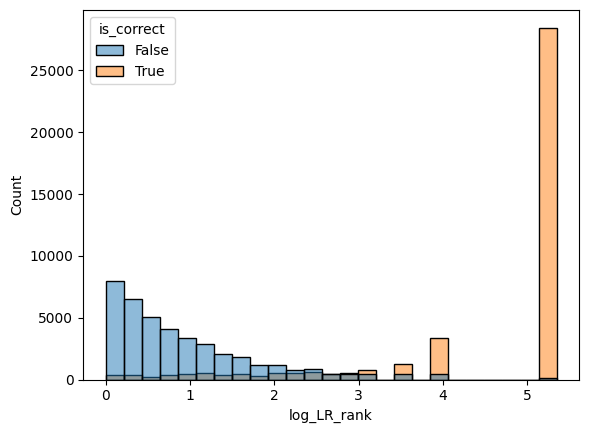

In [ ]:
df_pos = df[df.is_correct].sample(40000)
df_neg = df[~df.is_correct].sample(40000)

sns.histplot(data=pd.concat([df_pos, df_neg]), x="log_LR_confidence", hue="is_correct")